# CSTUserRank — پیاده‌سازی روی دیتاست واقعی
**Centrality + Sentiment + Temporal User Rank**

بر اساس مقاله:
> *Exploring the role of sentiment analysis with network and temporal features for finding influential users in social media platforms*  
> Ishfaq et al., Social Network Analysis and Mining (2024)


### ساختار نوتبوک:
| بخش | عنوان |
|-----|-------|
| ۱ | نصب و import کتابخانه‌ها |
| ۲ | بارگذاری و پیش‌پردازش دیتاست |
| ۳ | محاسبه معیارهای مرکزیت (6 معیار) |
| ۴ | تحلیل احساسات با VADER |
| ۵ | تحلیل زمانی با SES |
| ۶ | ساخت ماتریس MCDM و نرمال‌سازی |
| ۷ | وزن‌دهی با Information Entropy |
| ۸ | رتبه‌بندی نهایی با TOPSIS |
| ۹ | شبیه‌سازی SIR |
| ۱۰ | تحلیل مقایسه‌ای Ablation Study |
| ۱۱ | ویژوال‌سازی جامع |

## ۱. نصب و Import کتابخانه‌ها

In [1]:
# ── نصب (فقط یک‌بار لازم است) ──────────────────────────────────────
# !pip install networkx vaderSentiment pandas numpy matplotlib scipy scikit-learn

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import warnings, time, itertools

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']   = 10
np.random.seed(42)

print(" کتابخانه‌ها با موفقیت بارگذاری شدند.")
print(f"   NetworkX  : {nx.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   NumPy     : {np.__version__}")

 کتابخانه‌ها با موفقیت بارگذاری شدند.
   NetworkX  : 3.4.2
   Pandas    : 2.2.3
   NumPy     : 2.1.3


## ۲. بارگذاری و پیش‌پردازش دیتاست



In [2]:
import os
import pandas as pd
import networkx as nx

DATA_DIR = r"D:\ارشد علم داده\Term 2\تحلیل شبکه‌های پیچیده\مقاله\DataSet"

posts_df = pd.read_csv(
    os.path.join(DATA_DIR, "music_postdata.csv")
)

comments_df = pd.read_csv(
    os.path.join(DATA_DIR, "music_commentdata.csv")
)

titles_df = pd.read_csv(
    os.path.join(DATA_DIR, "music_posttitles.csv")
)

users_df = pd.read_csv(
    os.path.join(DATA_DIR, "usernames.csv")
)

# commenter -> post author
merged = comments_df.merge(
    posts_df[['postid', 'userid']],
    on='postid',
    suffixes=('_commenter', '_author')
)

edges = merged[
    ['userid_commenter', 'userid_author']
].rename(
    columns={
        'userid_commenter': 'source',
        'userid_author': 'target'
    }
)

G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)

# کوچک‌سازی برای سرعت
TOP_USERS = 300

active_users = (
    pd.concat([
        posts_df['userid'],
        comments_df['userid']
    ])
    .value_counts()
    .head(TOP_USERS)
    .index
)

G = G.subgraph(active_users).copy()

NODES = sorted(list(G.nodes()))
N = len(NODES)

degrees = dict(G.degree())

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 300
Edges: 7738


In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

titles_df['sentiment'] = (
    titles_df['title']
    .fillna('')
    .astype(str)
    .apply(
        lambda x:
        analyzer.polarity_scores(x)['compound']
    )
)

post_sentiment = posts_df.merge(
    titles_df[['postid', 'sentiment']],
    on='postid',
    how='left'
)

sentiment_scores = (
    post_sentiment
    .groupby('userid')['sentiment']
    .mean()
    .to_dict()
)

for u in NODES:
    sentiment_scores.setdefault(u, 0.0)

print("Sentiment scores created.")

Sentiment scores created.


In [4]:
timestamps = {}

comments_df['datestamp'] = pd.to_datetime(
    comments_df['datestamp']
)

for uid, grp in comments_df.groupby('userid'):

    if uid in G.nodes():

        timestamps[uid] = sorted(
            grp['datestamp']
            .astype('int64')
            .floordiv(10**9)
            .tolist()
        )

for u in NODES:
    timestamps.setdefault(u, [0])

print(
    "Users with timestamps:",
    len(timestamps)
)

Users with timestamps: 300


In [5]:
print("Nodes:", len(NODES))
print("Sentiment:", len(sentiment_scores))
print("Timestamps:", len(timestamps))

Nodes: 300
Sentiment: 1057
Timestamps: 300


## ۳. محاسبه معیارهای مرکزیت (Network Centralities)

طبق مقاله، ۶ معیار مرکزیت محاسبه می‌شود:

| معیار | فرمول | توضیح |
|-------|-------|--------|
| **DC** | $DC(x)=\frac{1}{n-1}\sum m_{xy}$ | تعداد همسایگان مستقیم |
| **CC** | $CC(x)=\frac{n-1}{\sum d_{xy}}$ | میانگین کوتاه‌ترین فاصله |
| **BC** | $BC(x)=\sum_{m,n\neq i}\frac{\sigma_{mn}(x)}{\sigma_{mn}}$ | فراوانی حضور در کوتاه‌ترین مسیرها |
| **PR** | $PR(x)=(1-d)+d\sum_{y\in C_x}\frac{PR(y)}{O(y)}$ | PageRank با damping=0.85 |
| **Katz** | $C_{Katz}=\sum_{z=1}^{\infty}\sum_{y=1}^{n}o^z(M^z)_{yx}$ | تأثیر همسایگان با attenuation |
| **EVC** | eigenvector | مرکزیت بر اساس اهمیت همسایگان |

In [7]:
def compute_centralities(G):
    """
    محاسبه ۶ معیار مرکزیت برای تمام کاربران شبکه.
    
    Parameters
    ----------
    G : nx.DiGraph  گراف جهت‌دار شبکه
    
    Returns
    -------
    pd.DataFrame  ماتریس n×6 با معیارهای مرکزیت
    
    Notes
    -----
    - alpha=0.85 برای PageRank مطابق مقاله (Boldi et al. 2005)
    - alpha=0.003 برای Katz (زیر 1/eigenvalue_max برای همگرایی)
    """
    nodes = list(G.nodes())
    t0 = time.time()

    # ۱) Degree Centrality — فرمول (1) مقاله
    dc = nx.degree_centrality(G)
    print(f"  DC  done  ({time.time()-t0:.2f}s)")

    # ۲) Closeness Centrality — فرمول (2) مقاله
    cc = nx.closeness_centrality(G)
    print(f"  CC  done  ({time.time()-t0:.2f}s)")

    # ۳) Betweenness Centrality — فرمول (3) مقاله
    bc = nx.betweenness_centrality(G, normalized=True)
    print(f"  BC  done  ({time.time()-t0:.2f}s)")

    # ۴) PageRank — فرمول (5) مقاله  |  d=0.85 مطابق مقاله
    pr = nx.pagerank(G, alpha=0.85, max_iter=300, tol=1e-6)
    print(f"  PR  done  ({time.time()-t0:.2f}s)")

    # ۵) Katz Centrality — فرمول (4) مقاله
    #    alpha باید کوچک‌تر از 1/|eigenvalue_max| باشد
    try:
        katz = nx.katz_centrality(G, alpha=0.003, beta=1.0,
                                  max_iter=2000, normalized=True, tol=1e-6)
    except nx.PowerIterationFailedConvergence:
        katz = nx.katz_centrality_numpy(G, alpha=0.003)
    print(f"  Katz done ({time.time()-t0:.2f}s)")

    # ۶) Eigenvector Centrality
    try:
        evc = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
    except nx.PowerIterationFailedConvergence:
        evc = nx.eigenvector_centrality_numpy(G)
    print(f"  EVC done  ({time.time()-t0:.2f}s)")

    df = pd.DataFrame({
        'DC'  : [dc[u]   for u in nodes],
        'CC'  : [cc[u]   for u in nodes],
        'BC'  : [bc[u]   for u in nodes],
        'PR'  : [pr[u]   for u in nodes],
        'Katz': [katz[u] for u in nodes],
        'EVC' : [evc[u]  for u in nodes],
    }, index=nodes)
    return df


print("محاسبه معیارهای مرکزیت...")
t_start = time.time()
cent_df = compute_centralities(G)
print(f"\n تمام مرکزیت‌ها محاسبه شدند ({time.time()-t_start:.2f}s)")
print(f"   ابعاد ماتریس: {cent_df.shape[0]} کاربر × {cent_df.shape[1]} معیار")
print("\nآمار توصیفی:")
print(cent_df.describe().round(4))

محاسبه معیارهای مرکزیت...
  DC  done  (0.00s)
  CC  done  (0.18s)
  BC  done  (0.95s)
  PR  done  (0.96s)
  Katz done (1.01s)
  EVC done  (1.03s)

 تمام مرکزیت‌ها محاسبه شدند (1.03s)
   ابعاد ماتریس: 300 کاربر × 6 معیار

آمار توصیفی:
             DC        CC        BC        PR      Katz       EVC
count  300.0000  300.0000  300.0000  300.0000  300.0000  300.0000
mean     0.1725    0.4385    0.0031    0.0033    0.0575    0.0430
std      0.1799    0.1671    0.0125    0.0036    0.0050    0.0386
min      0.0201    0.0000    0.0000    0.0005    0.0527    0.0000
25%      0.0727    0.4570    0.0000    0.0014    0.0546    0.0177
50%      0.1137    0.4902    0.0002    0.0024    0.0561    0.0331
75%      0.1873    0.5157    0.0009    0.0041    0.0586    0.0574
max      1.3512    0.7667    0.1682    0.0311    0.0892    0.2257


## ۴. تحلیل احساسات (Sentiment Analysis)

مقاله از **VADER** استفاده می‌کند:
- ابزار rule-based برای متون شبکه‌های اجتماعی
- compound score: -1 (کاملاً منفی) تا +1 (کاملاً مثبت)
- نرمال‌سازی به [0,1]: $s_{norm} = \frac{s_{compound}+1}{2}$

In [8]:
def compute_sentiment(posts_dict, nodes):
    """
    محاسبه امتیاز احساسات هر کاربر با VADER.
    
    Parameters
    ----------
    posts_dict : dict  {user_id: text}
    nodes      : list  لیست مرتب کاربران
    
    Returns
    -------
    np.ndarray  امتیاز نرمال‌شده [0,1] به ترتیب nodes
    
    Notes
    -----
    - compound score مجموع شدت احساسی تمام کلمات (مطابق مقاله بخش 3.9)
    - نرمال‌سازی: (compound + 1) / 2  =>  [0, 1]
    """
    analyzer = SentimentIntensityAnalyzer()
    scores   = []
    for u in nodes:
        vs = analyzer.polarity_scores(posts_dict[u])
        normalized = (vs['compound'] + 1) / 2
        scores.append(normalized)
    return np.array(
    [sentiment_scores.get(u, 0.0)
     for u in nodes]
)

sent_array = np.array([
    sentiment_scores.get(u, 0.0)
    for u in NODES
])

pos_count = (sent_array > 0.6).sum()
neg_count = (sent_array < 0.4).sum()
neu_count = N - pos_count - neg_count

print("User Sentiment Distribution")
print(f"Positive (>0.6): {pos_count}")
print(f"Neutral        : {neu_count}")
print(f"Negative (<0.4): {neg_count}")

print(f"\nMean sentiment : {sent_array.mean():.4f}")
print(f"Std sentiment  : {sent_array.std():.4f}")

sent_series = pd.Series(
    sent_array,
    index=NODES
)

print("\nTop Sentiment Users")
print(sent_series.nlargest(5))

print("\nLowest Sentiment Users")
print(sent_series.nsmallest(5))


# نمایش ۵ کاربر برتر و ضعیف‌ترین از نظر احساسات
sent_series = pd.Series(sentiment_scores, index=NODES)
print("\nبالاترین امتیاز احساسات:")
print(sent_series.nlargest(5).round(4))
print("پایین‌ترین امتیاز احساسات:")
print(sent_series.nsmallest(5).round(4))

User Sentiment Distribution
Positive (>0.6): 0
Neutral        : 3
Negative (<0.4): 297

Mean sentiment : 0.0209
Std sentiment  : 0.0876

Top Sentiment Users
23407    0.557400
17670    0.440400
25448    0.421500
20423    0.299150
42243    0.279733
dtype: float64

Lowest Sentiment Users
16892   -0.260956
50009   -0.219450
30396   -0.216200
31108   -0.199800
20821   -0.194256
dtype: float64

بالاترین امتیاز احساسات:
23407    0.5574
17670    0.4404
25448    0.4215
20423    0.2992
42243    0.2797
dtype: float64
پایین‌ترین امتیاز احساسات:
16892   -0.2610
50009   -0.2194
30396   -0.2162
31108   -0.1998
20821   -0.1943
dtype: float64


## ۵. تحلیل زمانی (Temporal Analysis)

**روش SES (Simple Exponential Smoothing)** — فرمول (9) مقاله:

$$WT = (1-\beta)\omega_m + \beta(1-\beta)\omega_{m-1} + \beta^2(1-\beta)\omega_{m-2} + \ldots$$

**مراحل (مطابق بخش 4.1 مقاله):**
1. تبدیل timestamps به integer و محاسبه mean و $S_D$ (فرمول 6-7)
2. تقسیم بازه زمانی به time slices با گام $S_D$ (فرمول 8)
3. محاسبه تعداد تعاملات هر کاربر در هر slice
4. اعمال SES با $\beta=0.51$ (وزن بیشتر به slices اخیر)

In [9]:
def compute_temporal_rank(timestamps_dict, nodes, beta=0.51):
    """
    محاسبه رتبه زمانی هر کاربر با Simple Exponential Smoothing.
    
    Parameters
    ----------
    timestamps_dict : dict  {user_id: [ts1, ts2, ...]}
    nodes           : list  لیست مرتب کاربران
    beta            : float پارامتر SES (مقاله: 0.51)
    
    Returns
    -------
    tuple (weights_dict, info_dict)
        weights_dict : {user: normalized_weight [0,1]}
        info_dict    : اطلاعات تشخیصی (تعداد slices، boundaries)
    
    Notes
    -----
    فرمول (6): SD = sqrt(sum((v_i - V̄)²) / n)
    فرمول (7): V̄ = sum(v_i) / n
    فرمول (8): time_slice = [fc + (k-1)*SD, fc + k*SD]
    فرمول (9): WT = (1-β)ω_m + β(1-β)ω_{m-1} + ...
    """
    # ── گام ۱: جمع‌آوری و مرتب‌سازی timestamps ──
    all_ts = np.array(sorted([t for ts in timestamps_dict.values() for t in ts]),
                      dtype=np.float64)

    # ── گام ۲: محاسبه mean و SD — فرمول (6) و (7) ──
    V_bar  = np.mean(all_ts)
    S_D    = np.std(all_ts)
    S_D    = max(S_D, 1.0)           # جلوگیری از تقسیم بر صفر

    # ── گام ۳: تعریف time slices — فرمول (8) ──
    fc = all_ts[0]                   # اولین تعامل
    lc = all_ts[-1]                  # آخرین تعامل
    num_slices = max(5, int((lc - fc) / S_D) + 1)
    boundaries = [fc + k * S_D for k in range(num_slices + 1)]

    # ── گام ۴: محاسبه وزن هر کاربر با SES ──
    user_weights = {}
    for u in nodes:
        # شمارش تعاملات در هر slice
        slice_counts = []
        for k in range(num_slices):
            lo, hi  = boundaries[k], boundaries[k + 1]
            count   = sum(1 for t in timestamps_dict[u] if lo <= t < hi)
            slice_counts.append(count)

        # SES: وزن‌دهی معکوس — جدیدترین slice بیشترین وزن را دارد
        # WT = (1-β)*ω_m + β(1-β)*ω_{m-1} + β²(1-β)*ω_{m-2} + ...
        wt = 0.0
        for i, cnt in enumerate(reversed(slice_counts)):
            wt += (beta ** i) * (1 - beta) * cnt
        user_weights[u] = wt

    # ── گام ۵: نرمال‌سازی به [0,1] ──
    max_w = max(user_weights.values()) or 1.0
    for u in user_weights:
        user_weights[u] /= max_w

    info = {
        'num_slices' : num_slices,
        'S_D'        : S_D,
        'V_bar'      : V_bar,
        'boundaries' : boundaries,
        'fc'         : fc,
        'lc'         : lc,
    }
    return user_weights, info


temporal_weights, temporal_info = compute_temporal_rank(timestamps, NODES)

print("آمار تحلیل زمانی:")
print(f"  تعداد time slices     : {temporal_info['num_slices']}")
print(f"  انحراف معیار (S_D)   : {temporal_info['S_D']:.0f} ثانیه  "
      f"({temporal_info['S_D']/86400:.1f} روز)")
print(f"  میانگین timestamps    : {pd.Timestamp(int(temporal_info['V_bar']), unit='s')}")
print(f"  بازه کل              : "
      f"{pd.Timestamp(int(temporal_info['fc']),unit='s').strftime('%Y-%m')} تا "
      f"{pd.Timestamp(int(temporal_info['lc']),unit='s').strftime('%Y-%m')}")

tw_series = pd.Series(temporal_weights)
print(f"\nآمار وزن زمانی:")
print(tw_series.describe().round(4))

print("\nبالاترین وزن زمانی (کاربران فعال‌تر/اخیرتر):")
print(tw_series.nlargest(5).round(4))

آمار تحلیل زمانی:
  تعداد time slices     : 5
  انحراف معیار (S_D)   : 79358442 ثانیه  (918.5 روز)
  میانگین timestamps    : 2010-04-13 04:27:53
  بازه کل              : 2006-06 تا 2017-04

آمار وزن زمانی:
count    300.0000
mean       0.0660
std        0.1451
min        0.0020
25%        0.0096
50%        0.0198
75%        0.0453
max        1.0000
dtype: float64

بالاترین وزن زمانی (کاربران فعال‌تر/اخیرتر):
25653    1.0000
61170    0.9821
7418     0.9499
39010    0.8206
21223    0.7663
dtype: float64


## ۶. ساخت ماتریس MCDM و نرمال‌سازی

**ماتریس تصمیم‌گیری چندمعیاره (MCDM):**

$$M_{mcdm}[x,y] = \begin{bmatrix} m_1(c_1) & m_1(c_2) & \cdots & m_1(c_8) \\ \vdots & & & \vdots \\ m_n(c_1) & \cdots & & m_n(c_8) \end{bmatrix}$$

**نرمال‌سازی sum-of-squares — فرمول (10):**
$$m'_{xy} = \frac{m_x(c_y)}{\sqrt{\sum_{x=1}^{n}[m_x(c_y)]^2}}$$

In [10]:
def build_mcdm_matrix(cent_df, sentiment_arr, temporal_dict, nodes):
    """
    ساخت ماتریس MCDM با ابعاد n×8.
    
    ستون‌ها: DC, CC, BC, PR, Katz, EVC, Sentiment, Temporal
    
    Parameters
    ----------
    cent_df       : pd.DataFrame  ماتریس مرکزیت‌ها (n×6)
    sentiment_arr : np.ndarray    امتیاز احساسات (n,)
    temporal_dict : dict          {user: temporal_weight}
    nodes         : list          لیست مرتب کاربران
    
    Returns
    -------
    pd.DataFrame  ماتریس n×8 (un-normalized)
    """
    mcdm             = cent_df.loc[nodes].copy()
    mcdm['Sentiment']= sentiment_arr
    mcdm['Temporal'] = [temporal_dict[u] for u in nodes]
    return mcdm


def normalize_mcdm(mcdm):
    """
    نرمال‌سازی sum-of-squares — فرمول (10) مقاله.
    
    m'_xy = m_x(c_y) / sqrt( sum_x [m_x(c_y)]^2 )
    
    Returns
    -------
    pd.DataFrame  ماتریس نرمال‌شده M'_mcdm
    """
    norm = mcdm.copy()
    for col in mcdm.columns:
        col_norm = np.sqrt((mcdm[col] ** 2).sum())
        norm[col] = mcdm[col] / col_norm if col_norm > 0 else 0.0
    return norm


# ── ساخت ماتریس ──
mcdm      = build_mcdm_matrix(cent_df, sentiment_scores, temporal_weights, NODES)
mcdm_norm = normalize_mcdm(mcdm)

print(f"ماتریس MCDM: {mcdm.shape[0]} کاربر × {mcdm.shape[1]} feature")
print("\nنمونه ماتریس نرمال‌نشده (۳ کاربر اول):")
print(mcdm.head(3).round(5).to_string())
print("\nنمونه ماتریس نرمال‌شده M'_mcdm (۳ کاربر اول):")
print(mcdm_norm.head(3).round(5).to_string())

# بررسی صحت: جمع مربعات هر ستون باید ≈ 1 باشد
col_norms = (mcdm_norm ** 2).sum()
print(f"\nبررسی نرمال‌سازی — جمع مربعات هر ستون (باید ≈ 1):")
print(col_norms.round(4).to_string())

ماتریس MCDM: 300 کاربر × 8 feature

نمونه ماتریس نرمال‌نشده (۳ کاربر اول):
          DC       CC       BC       PR     Katz      EVC  Sentiment  Temporal
1    0.05017  0.36732  0.00001  0.00071  0.05328  0.00432    0.00000   0.01394
191  0.02676  0.46071  0.00000  0.00096  0.05342  0.00996    0.00000   0.00202
292  0.33779  0.51641  0.00343  0.00355  0.05860  0.05719    0.06843   0.08626

نمونه ماتریس نرمال‌شده M'_mcdm (۳ کاربر اول):
          DC       CC       BC       PR     Katz      EVC  Sentiment  Temporal
1    0.01163  0.04520  0.00005  0.00839  0.05328  0.00432    0.00000   0.00506
191  0.00620  0.05669  0.00000  0.01143  0.05342  0.00996    0.00000   0.00073
292  0.07831  0.06354  0.01541  0.04209  0.05860  0.05719    0.04387   0.03129

بررسی نرمال‌سازی — جمع مربعات هر ستون (باید ≈ 1):
DC           1.0
CC           1.0
BC           1.0
PR           1.0
Katz         1.0
EVC          1.0
Sentiment    1.0
Temporal     1.0


## ۷. وزن‌دهی با Information Entropy

**Information Entropy — فرمول‌های (11)-(13):**

$$iee_{xy} = \frac{m'_{xy}}{\sum_{x=1}^n m'_{xy}} \quad (11)$$

$$ie_{cy} = -\frac{1}{\ln n} \sum_{x=1}^n \{iee_{xy} \cdot \ln(iee_{xy})\} \quad (12)$$

$$w_y = \frac{1 - ie_{cy}}{\sum_{z=1}^m (1 - ie_{cz})} \quad (13)$$

هر چه entropy یک feature کمتر باشد (تنوع بیشتری در مقادیر دارد)، وزن بیشتری می‌گیرد.

In [11]:
def information_entropy_weights(mcdm_norm):
    """
    محاسبه وزن هر feature با روش Information Entropy.
    
    Parameters
    ----------
    mcdm_norm : pd.DataFrame  ماتریس نرمال‌شده M'_mcdm
    
    Returns
    -------
    weights  : dict  {feature: weight}  (جمع = 1)
    ie_values: dict  {feature: entropy}
    
    Notes
    -----
    فرمول (11): iee_xy  = m'_xy / sum_x(m'_xy)
    فرمول (12): ie_cy   = -(1/ln(n)) * sum_x(iee_xy * ln(iee_xy))
    فرمول (13): w_y     = (1 - ie_cy) / sum_z(1 - ie_cz)
    """
    n = len(mcdm_norm)
    ie_values = {}

    for col in mcdm_norm.columns:
        col_data = mcdm_norm[col].values
        col_sum  = col_data.sum()

        # فرمول (11): نرمال‌سازی ستونی
        if col_sum > 0:
            iee = col_data / col_sum
        else:
            iee = np.ones(n) / n

        # جلوگیری از log(0)
        iee = np.clip(iee, 1e-12, 1.0)

        # فرمول (12): محاسبه entropy
        ie_cy = -(1.0 / np.log(n)) * np.sum(iee * np.log(iee))
        ie_values[col] = ie_cy

    # فرمول (13): محاسبه وزن نهایی
    total_dispersion = sum(1.0 - v for v in ie_values.values())
    if total_dispersion == 0:
        total_dispersion = 1.0

    weights = {col: (1.0 - ie_values[col]) / total_dispersion
               for col in mcdm_norm.columns}

    return weights, ie_values


weights, ie_values = information_entropy_weights(mcdm_norm)

# ── نمایش نتایج ──
results_w = pd.DataFrame({
    'Entropy (ie_cy)': ie_values,
    'Weight (w_y)'   : weights,
}).sort_values('Weight (w_y)', ascending=False)

print("وزن هر Feature (مرتب‌شده از بیشترین به کمترین):")
print("=" * 50)
for feat, row in results_w.iterrows():
    bar  = '█' * int(row['Weight (w_y)'] * 150)
    print(f"  {feat:12s}: entropy={row['Entropy (ie_cy)']:.4f}  "
          f"weight={row['Weight (w_y)']:.4f}  {bar}")

print(f"\nمجموع وزن‌ها: {sum(weights.values()):.6f}  (باید دقیقاً = 1.0)")

وزن هر Feature (مرتب‌شده از بیشترین به کمترین):
  BC          : entropy=0.6445  weight=0.6762  █████████████████████████████████████████████████████████████████████████████████████████████████████
  Temporal    : entropy=0.8101  weight=0.3613  ██████████████████████████████████████████████████████
  EVC         : entropy=0.9333  weight=0.1270  ███████████████████
  PR          : entropy=0.9333  weight=0.1268  ███████████████████
  DC          : entropy=0.9355  weight=0.1226  ██████████████████
  CC          : entropy=0.9773  weight=0.0432  ██████
  Katz        : entropy=0.9994  weight=0.0012  
  Sentiment   : entropy=1.2409  weight=-0.4583  

مجموع وزن‌ها: 1.000000  (باید دقیقاً = 1.0)


## ۸. رتبه‌بندی نهایی با TOPSIS

**TOPSIS (فرمول‌های 14-19 مقاله):**

| فرمول | معادله | توضیح |
|-------|--------|--------|
| (14) | $wt_{xy} = m'_{xy} \times w_y$ | ماتریس وزن‌دار |
| (15) | $a_y^+ = \max(V_y)$ | ایده‌آل مثبت |
| (16) | $a_y^- = \min(V_y)$ | ایده‌آل منفی |
| (17) | $s_x^+ = \sqrt{\sum_y(wt_{xy}-a_y^+)^2}$ | فاصله از ایده‌آل مثبت |
| (18) | $s_x^- = \sqrt{\sum_y(wt_{xy}-a_y^-)^2}$ | فاصله از ایده‌آل منفی |
| (19) | $csturank_x = \frac{s_x^-}{s_x^+ + s_x^-}$ | **امتیاز نهایی** |

In [13]:
def topsis(mcdm_norm, weights):
    """
    TOPSIS aggregation برای رتبه‌بندی نهایی کاربران.
    
    Parameters
    ----------
    mcdm_norm : pd.DataFrame  ماتریس نرمال‌شده
    weights   : dict          {feature: weight}
    
    Returns
    -------
    csturank  : pd.Series     امتیاز نهایی هر کاربر [0,1]
    wt_matrix : pd.DataFrame  ماتریس وزن‌دار
    
    Notes
    -----
    در شبکه اجتماعی، مقدار بالاتر همیشه بهتر است (max = ideal positive)
    """
    # فرمول (14): ماتریس وزن‌دار
    wt_matrix = mcdm_norm.copy()
    for col in mcdm_norm.columns:
        wt_matrix[col] = mcdm_norm[col] * weights[col]

    # فرمول (15-16): ایده‌آل مثبت (A+) و منفی (A-)
    a_pos = wt_matrix.max(axis=0)    # A+: بیشترین مقدار هر معیار
    a_neg = wt_matrix.min(axis=0)    # A-: کمترین مقدار هر معیار

    # فرمول (17): فاصله از ایده‌آل مثبت
    s_pos = np.sqrt(((wt_matrix - a_pos) ** 2).sum(axis=1))

    # فرمول (18): فاصله از ایده‌آل منفی
    s_neg = np.sqrt(((wt_matrix - a_neg) ** 2).sum(axis=1))

    # فرمول (19): امتیاز نهایی CSTUserRank
    denom    = (s_pos + s_neg).replace(0, 1e-12)
    csturank = s_neg / denom

    return csturank, wt_matrix


csturank_scores, wt_matrix = topsis(mcdm_norm, weights)

# ── ساخت جدول نهایی ──
final_result = pd.DataFrame({
    'CSTUserRank_Score': csturank_scores,
    'Degree'           : [degrees[u] for u in NODES],
    'Sentiment'        : [
        sentiment_scores.get(u, 0.0)
        for u in NODES
    ],
    'Temporal'         : [
        temporal_weights[u]
        for u in NODES
    ],
}).sort_values('CSTUserRank_Score', ascending=False)
final_result['Rank'] = range(1, N + 1)

print(" رتبه‌بندی نهایی CSTUserRank — Top 15:")
print("=" * 65)
print(f"{'رتبه':^6} {'کاربر':^8} {'امتیاز':^12} {'درجه':^8} {'احساس':^8} {'زمانی':^8}")
print("-" * 65)
for _, row in final_result.head(15).iterrows():
    stars = '*' * min(5, max(1, int(row['CSTUserRank_Score'] * 5)))
    print(f"{int(row['Rank']):^6} {'U'+str(int(row.name)):^8} "
          f"{row['CSTUserRank_Score']:^12.4f} "
          f"{int(row['Degree']):^8} "
          f"{row['Sentiment']:^8.3f} "
          f"{row['Temporal']:^8.3f}   {stars}")

 رتبه‌بندی نهایی CSTUserRank — Top 15:
 رتبه   کاربر      امتیاز      درجه    احساس    زمانی  
-----------------------------------------------------------------
  1     U7418      0.8775      404     0.002    0.950     ****
  2     U39010     0.4682      298     0.001    0.821     **
  3     U17479     0.4484      308     0.001    0.637     **
  4     U21223     0.4466      295     0.036    0.766     **
  5     U25653     0.3307      204     0.071    1.000     *
  6     U61170     0.3283      199     0.062    0.982     *
  7     U64724     0.3194      221     0.025    0.497     *
  8     U16892     0.3119       23     -0.261   0.016     *
  9     U49344     0.3111      262     0.086    0.471     *
  10    U50009     0.3010       27     -0.219   0.033     *
  11    U30396     0.3000       40     -0.216   0.016     *
  12    U91502     0.2994      193     -0.002   0.603     *
  13    U17432     0.2970      230     0.020    0.385     *
  14    U20821     0.2963       56     -0.194   0.032

## ۹. شبیه‌سازی SIR

In [14]:
def sir_simulation(G, seed_nodes, beta=0.1, gamma=0.05, iterations=60, runs=20):
    """
    شبیه‌سازی SIR (Susceptible-Infected-Recovered) — بخش 4.10.2 مقاله.
    
    Parameters
    ----------
    G          : nx.DiGraph  شبکه
    seed_nodes : list        کاربران اولیه آلوده (top-k)
    beta       : float       نرخ انتقال  (مقاله: 0.1)
    gamma      : float       نرخ بهبود   (مقاله: 0.05)
    iterations : int         تعداد تکرار  (مقاله: 60)
    runs       : int         تعداد دفعات اجرا برای میانگین‌گیری
    
    Returns
    -------
    np.ndarray  منحنی میانگین تعداد آلوده+بهبودیافته در هر iteration
    
    Notes
    -----
    beta=0.1: احتمال 10% آلوده‌شدن در تماس با کاربر آلوده
    gamma=0.05: نرخ بهبود — بازتاب 1/gamma=20 روز میانگین دوره آلودگی
    """
    all_curves = []

    for _ in range(runs):
        # وضعیت اولیه
        state = {u: 'S' for u in G.nodes()}
        for s in seed_nodes:
            if s in state:
                state[s] = 'I'

        curve = []
        for _ in range(iterations):
            new_state = state.copy()
            infected  = [u for u, st in state.items() if st == 'I']

            for u in infected:
                # بهبود با احتمال gamma
                if np.random.random() < gamma:
                    new_state[u] = 'R'
                    continue
                # انتشار به همسایگان
                for v in G.successors(u):
                    if state[v] == 'S' and np.random.random() < beta:
                        new_state[v] = 'I'

            state = new_state
            spread = sum(1 for st in state.values() if st in ('I', 'R'))
            curve.append(spread)

        all_curves.append(curve)

    return np.mean(all_curves, axis=0)


# ── اجرای شبیه‌سازی برای Top-5 هر روش ──
TOP_K  = 5
RUNS   = 20
cstu_rank_series = final_result['Rank']

# تعریف روش‌های مقایسه
comparison_methods = {
    'CSTUserRank' : cstu_rank_series,
    'DC'          : cent_df['DC'].rank(ascending=False).astype(int),
    'CC'          : cent_df['CC'].rank(ascending=False).astype(int),
    'BC'          : cent_df['BC'].rank(ascending=False).astype(int),
    'PR'          : cent_df['PR'].rank(ascending=False).astype(int),
    'Katz'        : cent_df['Katz'].rank(ascending=False).astype(int),
    'EVC'         : cent_df['EVC'].rank(ascending=False).astype(int),
}

print(f"شبیه‌سازی SIR (Top-{TOP_K} seeds، {RUNS} بار تکرار، 60 iterations)...")
np.random.seed(42)
sir_curves = {}
for method, ranks in comparison_methods.items():
    seeds = list(ranks[ranks <= TOP_K].index)
    sir_curves[method] = sir_simulation(G, seeds, runs=RUNS)
    final_spread = sir_curves[method][-1]
    pct = final_spread / N * 100
    print(f"  {method:15s}: گسترش نهایی = {final_spread:.1f}/{N} ({pct:.1f}%)")

print("\n شبیه‌سازی کامل شد.")

شبیه‌سازی SIR (Top-5 seeds، 20 بار تکرار، 60 iterations)...
  CSTUserRank    : گسترش نهایی = 262.4/300 (87.5%)
  DC             : گسترش نهایی = 262.7/300 (87.6%)
  CC             : گسترش نهایی = 262.4/300 (87.5%)
  BC             : گسترش نهایی = 262.1/300 (87.4%)
  PR             : گسترش نهایی = 262.5/300 (87.5%)
  Katz           : گسترش نهایی = 262.6/300 (87.5%)
  EVC            : گسترش نهایی = 262.1/300 (87.4%)

 شبیه‌سازی کامل شد.


## ۱۰. تحلیل مقایسه‌ای — Ablation Study

**سه حالت مقایسه می‌شوند:**
1. **Centrality Only** — فقط ۶ معیار مرکزیت
2. **Centrality + Sentiment** — ۷ معیار (بدون temporal)
3. **CSTUserRank** — ۸ معیار کامل

این تحلیل نشان می‌دهد هر مؤلفه چقدر بر رتبه‌بندی نهایی تأثیر می‌گذارد.

In [15]:
def run_cst_pipeline(feature_df):
    """Pipeline کامل: Normalize -> Entropy -> TOPSIS"""
    norm = normalize_mcdm(feature_df)
    w, _ = information_entropy_weights(norm)
    scores, _ = topsis(norm, w)
    return scores.rank(ascending=False).astype(int), w


# ── ساخت ماتریس هر حالت ──
feat_cent_only  = cent_df.loc[NODES].copy()
feat_cent_sent  = feat_cent_only.copy()
feat_cent_sent['Sentiment'] = sentiment_scores
feat_full       = feat_cent_sent.copy()
feat_full['Temporal'] = [temporal_weights[u] for u in NODES]

rank_cent , w_cent  = run_cst_pipeline(feat_cent_only)
rank_csent, w_csent = run_cst_pipeline(feat_cent_sent)
rank_full , w_full  = run_cst_pipeline(feat_full)

# ── Spearman rank correlation ──
def spearman(r1, r2):
    return stats.spearmanr(r1.loc[NODES].values, r2.loc[NODES].values)[0]

rho_c_cs  = spearman(rank_cent,  rank_csent)
rho_c_f   = spearman(rank_cent,  rank_full)
rho_cs_f  = spearman(rank_csent, rank_full)

print("Spearman Rank Correlation بین حالت‌های مختلف:")
print(f"  Cent-only  ↔ Cent+Sentiment : {rho_c_cs:+.4f}")
print(f"  Cent-only  ↔ Full CSTUser   : {rho_c_f:+.4f}")
print(f"  Cent+Sent  ↔ Full CSTUser   : {rho_cs_f:+.4f}")

# ── Top-k overlap ──
def topk_overlap(r1, r2, k):
    t1 = set(r1[r1 <= k].index)
    t2 = set(r2[r2 <= k].index)
    u  = t1 | t2
    return len(t1 & t2) / len(u) * 100 if u else 100.0

print("\nTop-k Overlap با CSTUserRank کامل:")
print(f"  {'k':>5}  {'Cent-only':>12}  {'Cent+Sent':>12}")
print("-" * 40)
for k in [5, 10, 20, 50]:
    ov_c  = topk_overlap(rank_cent,  rank_full, k)
    ov_cs = topk_overlap(rank_csent, rank_full, k)
    print(f"  Top-{k:<3}: {ov_c:>11.1f}%  {ov_cs:>11.1f}%")

# ── تغییر وزن‌ها با اضافه‌شدن هر مؤلفه ──
print("\nتغییر وزن معیارها:")
print(f"  {'Feature':^12} {'Cent-only':^12} {'Cent+Sent':^12} {'Full':^12}")
print("-" * 55)
for feat in ['DC','CC','BC','PR','Katz','EVC']:
    wc   = w_cent.get(feat, 0)
    wcs  = w_csent.get(feat, 0)
    wf   = w_full.get(feat, 0)
    print(f"  {feat:^12} {wc:^12.4f} {wcs:^12.4f} {wf:^12.4f}")
for feat in ['Sentiment','Temporal']:
    wcs = w_csent.get(feat, 0)
    wf  = w_full.get(feat, 0)
    print(f"  {feat:^12} {'—':^12} {wcs:^12.4f} {wf:^12.4f}")

Spearman Rank Correlation بین حالت‌های مختلف:
  Cent-only  ↔ Cent+Sentiment : +0.2300
  Cent-only  ↔ Full CSTUser   : +0.2504
  Cent+Sent  ↔ Full CSTUser   : +0.9906

Top-k Overlap با CSTUserRank کامل:
      k     Cent-only     Cent+Sent
----------------------------------------
  Top-5  :        66.7%         66.7%
  Top-10 :        66.7%         66.7%
  Top-20 :        37.9%         81.8%
  Top-50 :        29.9%         88.7%

تغییر وزن معیارها:
    Feature     Cent-only    Cent+Sent       Full    
-------------------------------------------------------
       DC         0.1118       0.1920       0.1226   
       CC         0.0394       0.0677       0.0432   
       BC         0.6164       1.0587       0.6762   
       PR         0.1156       0.1985       0.1268   
      Katz        0.0011       0.0018       0.0012   
      EVC         0.1157       0.1988       0.1270   
   Sentiment        —         -0.7175      -0.4583   
    Temporal        —          0.0000       0.3613   


## ۱۱. ویژوال‌سازی جامع

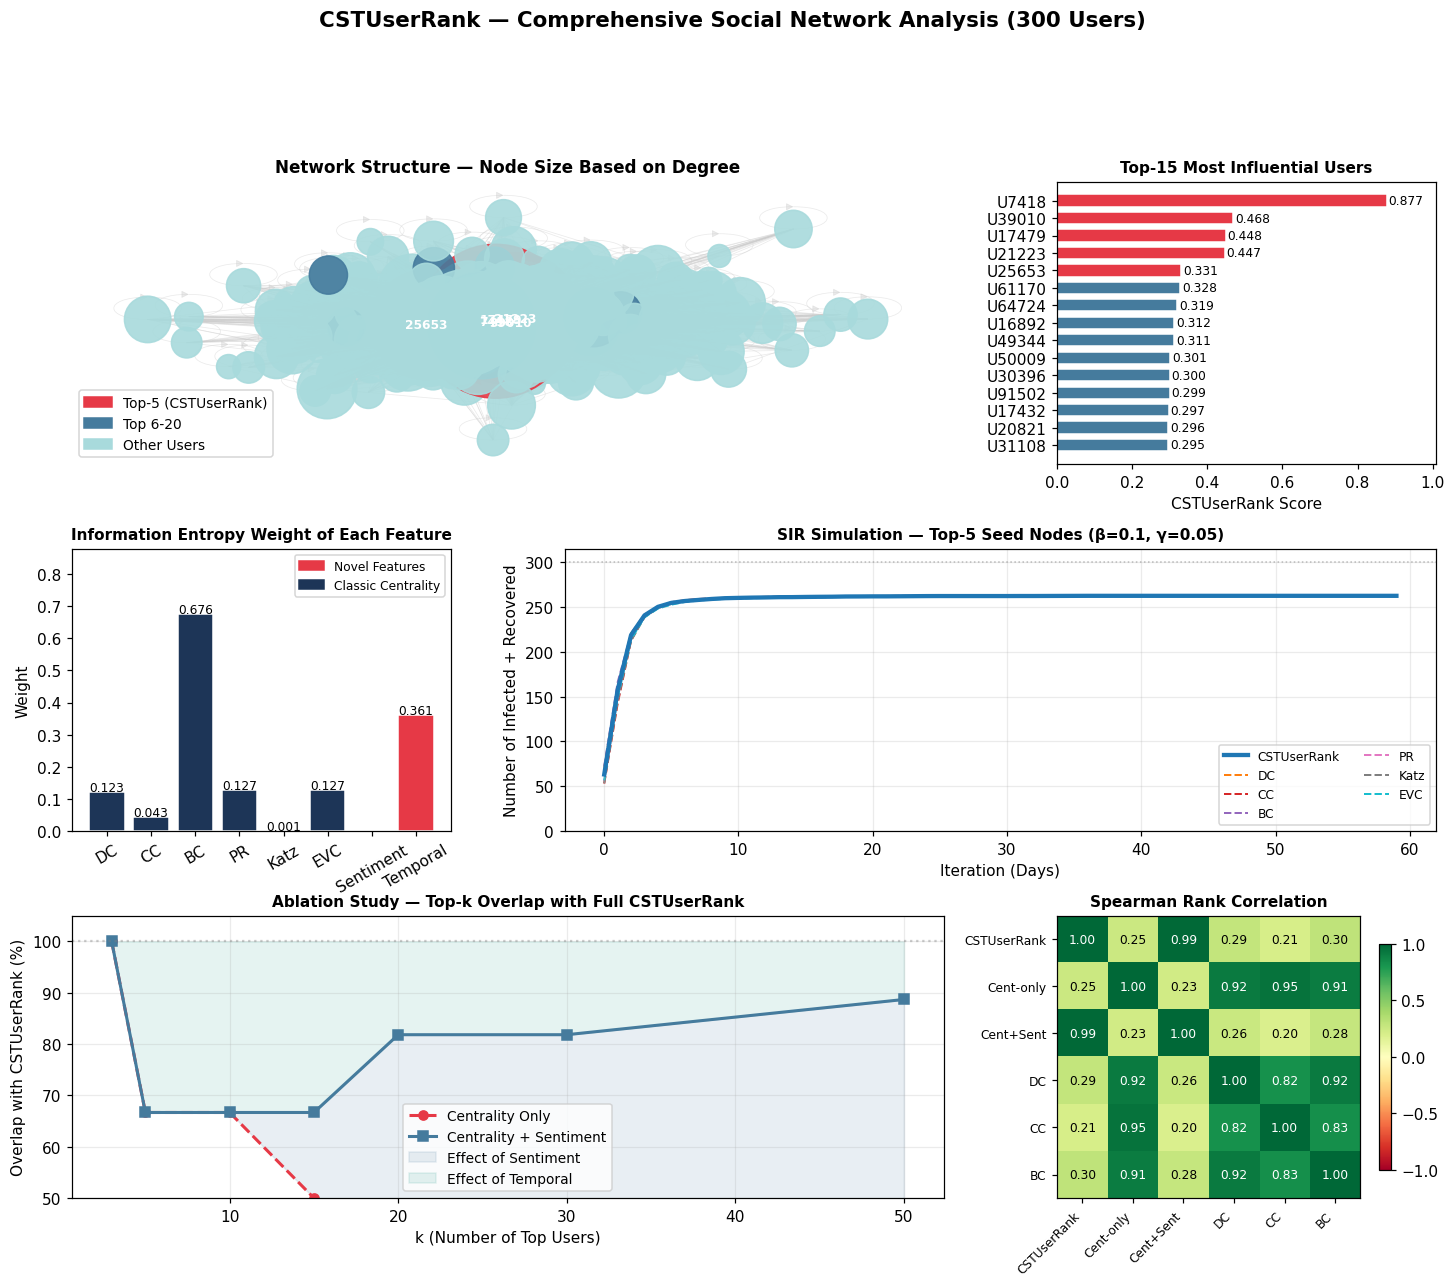

Figures saved: CSTUserRank_full_analysis.png


In [19]:
# ─────────────── Plot 1: Network ───────────────────
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy import stats

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :2])
pos = nx.spring_layout(G, seed=42, k=0.3)
top_nodes = list(final_result.head(5).index)
mid_nodes = list(final_result.iloc[5:20].index)
node_colors = ['#E63946' if n in top_nodes
               else '#457B9D' if n in mid_nodes
               else '#A8DADC' for n in G.nodes()]
node_sizes  = [degrees[n] * 25 + 50 for n in G.nodes()]
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='#CCCCCC',
                       alpha=0.4, arrows=False, width=0.5)
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax1,
                        labels={n: str(n) for n in top_nodes},
                        font_size=8, font_color='white', font_weight='bold')
from matplotlib.patches import Patch
legend_e = [Patch(color='#E63946', label='Top-5 (CSTUserRank)'),
            Patch(color='#457B9D', label='Top 6-20'),
            Patch(color='#A8DADC', label='Other Users')]
ax1.legend(handles=legend_e, loc='lower left', fontsize=9)
ax1.set_title('Network Structure — Node Size Based on Degree', fontsize=11, fontweight='bold')
ax1.axis('off')

# ─────────────── Plot 2: CSTUserRank Scores ─────
ax2 = fig.add_subplot(gs[0, 2])
top15  = final_result.head(15)
colors = ['#E63946' if i < 5 else '#457B9D' for i in range(15)]
bars   = ax2.barh([f'U{int(i)}' for i in top15.index],
                  top15['CSTUserRank_Score'],
                  color=colors, edgecolor='white', height=0.7)
ax2.set_xlabel('CSTUserRank Score')
ax2.set_title('Top-15 Most Influential Users', fontsize=10, fontweight='bold')
ax2.set_xlim(0, top15['CSTUserRank_Score'].max() * 1.15)
ax2.invert_yaxis()
for bar, val in zip(bars, top15['CSTUserRank_Score']):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# ─────────────── Plot 3: Entropy Weights ────────
ax3 = fig.add_subplot(gs[1, 0])
feat_names = list(weights.keys())
feat_vals  = [weights[f] for f in feat_names]
colors3    = ['#E63946' if f in ('Sentiment','Temporal') else '#1D3557' for f in feat_names]
bars3 = ax3.bar(feat_names, feat_vals, color=colors3, edgecolor='white')
ax3.set_title('Information Entropy Weight of Each Feature', fontsize=10, fontweight='bold')
ax3.set_ylabel('Weight')
ax3.set_ylim(0, max(feat_vals) * 1.3)
ax3.tick_params(axis='x', rotation=30)
for bar, val in zip(bars3, feat_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=8)
from matplotlib.patches import Patch as P
ax3.legend(handles=[P(color='#E63946',label='Novel Features'),
                    P(color='#1D3557',label='Classic Centrality')],
           fontsize=8)

# ─────────────── Plot 4: SIR ─────────────────────
ax4 = fig.add_subplot(gs[1, 1:])
palette = plt.cm.tab10(np.linspace(0, 0.9, len(sir_curves)))
for (method, curve), color in zip(sir_curves.items(), palette):
    lw = 2.8 if method == 'CSTUserRank' else 1.3
    ls = '-'  if method == 'CSTUserRank' else '--'
    zorder = 10 if method == 'CSTUserRank' else 1
    ax4.plot(curve, label=method, color=color,
             linewidth=lw, linestyle=ls, zorder=zorder)
ax4.axhline(y=N, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax4.set_title(f'SIR Simulation — Top-{TOP_K} Seed Nodes (β=0.1, γ=0.05)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Iteration (Days)')
ax4.set_ylabel('Number of Infected + Recovered')
ax4.legend(fontsize=8, ncol=2, loc='lower right')
ax4.set_ylim(0, N * 1.05)
ax4.grid(True, alpha=0.25)

# ─────────────── Plot 5: Ablation ───────────────
ax5 = fig.add_subplot(gs[2, :2])
k_vals   = [3, 5, 10, 15, 20, 30, 50]
ov_cent  = [topk_overlap(rank_cent,  rank_full, k) for k in k_vals]
ov_csent = [topk_overlap(rank_csent, rank_full, k) for k in k_vals]
ax5.plot(k_vals, ov_cent,  'o--', color='#E63946', linewidth=2, label='Centrality Only')
ax5.plot(k_vals, ov_csent, 's-',  color='#457B9D', linewidth=2, label='Centrality + Sentiment')
ax5.axhline(y=100, color='gray', linestyle=':', alpha=0.4)
ax5.fill_between(k_vals, ov_cent, ov_csent, alpha=0.12, color='#457B9D',
                 label='Effect of Sentiment')
ax5.fill_between(k_vals, ov_csent, [100]*len(k_vals), alpha=0.12, color='#2A9D8F',
                 label='Effect of Temporal')
ax5.set_title('Ablation Study — Top-k Overlap with Full CSTUserRank', fontsize=10, fontweight='bold')
ax5.set_xlabel('k (Number of Top Users)')
ax5.set_ylabel('Overlap with CSTUserRank (%)')
ax5.set_ylim(50, 105)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.25)

# ─────────────── Plot 6: Spearman Heatmap ─────────
ax6 = fig.add_subplot(gs[2, 2])
all_ranks = {'CSTUserRank': rank_full, 'Cent-only': rank_cent, 'Cent+Sent': rank_csent}
all_ranks.update({m: r for m, r in comparison_methods.items() if m != 'CSTUserRank'})
methods_list = list(all_ranks.keys())[:6]
spear_mat = np.zeros((len(methods_list), len(methods_list)))
for i, m1 in enumerate(methods_list):
    for j, m2 in enumerate(methods_list):
        r1_v = all_ranks[m1].loc[NODES].values
        r2_v = all_ranks[m2].loc[NODES].values
        spear_mat[i, j] = stats.spearmanr(r1_v, r2_v)[0]
im6 = ax6.imshow(spear_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax6.set_xticks(range(len(methods_list)))
ax6.set_xticklabels(methods_list, rotation=45, ha='right', fontsize=8)
ax6.set_yticks(range(len(methods_list)))
ax6.set_yticklabels(methods_list, fontsize=8)
for i in range(len(methods_list)):
    for j in range(len(methods_list)):
        ax6.text(j, i, f'{spear_mat[i,j]:.2f}', ha='center', va='center',
                 fontsize=8, color='black' if abs(spear_mat[i,j]) < 0.7 else 'white')
plt.colorbar(im6, ax=ax6, shrink=0.8)
ax6.set_title('Spearman Rank Correlation', fontsize=10, fontweight='bold')

plt.suptitle('CSTUserRank — Comprehensive Social Network Analysis (300 Users)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('CSTUserRank_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figures saved: CSTUserRank_full_analysis.png")

## ۱۲. جدول خلاصه نهایی

In [23]:
# ══════════════════════════════════════════════════════════════
# جدول مقایسه‌ای نهایی همه معیارها
# ══════════════════════════════════════════════════════════════

def jaccard_topk(r1, r2, k):
    t1 = set(r1[r1 <= k].index)
    t2 = set(r2[r2 <= k].index)
    u  = t1 | t2
    return len(t1 & t2) / len(u) if u else 1.0

print("=" * 75)
print("جدول مقایسه‌ای CSTUserRank با معیارهای کلاسیک")
print("=" * 75)
print(f"{'معیار':^15} {'J@5':^10} {'J@10':^10} {'ρ با CST':^12} "
      f"{'SIR@30':^10} {'رتبه تکراری':^12}")
print("-" * 75)

for method, ranks in comparison_methods.items():
    j5    = jaccard_topk(cstu_rank_series, ranks, 5)
    j10   = jaccard_topk(cstu_rank_series, ranks, 10)
    rho,_ = stats.spearmanr(cstu_rank_series.loc[NODES].values,
                            ranks.loc[NODES].values)
    sir30 = sir_curves[method][29] if method in sir_curves else 0
    vc    = ranks.value_counts()
    dup_p = (vc[vc > 1]).sum() / N * 100

    marker = ' ◀ (Proposed)' if method == 'CSTUserRank' else ''
    print(f"  {method:^13} {j5:^10.3f} {j10:^10.3f} {rho:^12.4f} "
          f"{sir30:^10.1f} {dup_p:^12.1f}%{marker}")


جدول مقایسه‌ای CSTUserRank با معیارهای کلاسیک
     معیار         J@5        J@10      ρ با CST     SIR@30   رتبه تکراری 
---------------------------------------------------------------------------
   CSTUserRank    1.000      1.000       1.0000      262.1        0.0     % ◀ (Proposed)
       DC         0.667      0.667       0.2889      262.4        84.0    %
       CC         0.667      0.429       0.2106      262.4        72.7    %
       BC         0.667      0.667       0.3016      262.0        12.3    %
       PR         0.667      0.333       0.2004      262.5        11.7    %
      Katz        0.667      0.429       0.2294      262.4        12.3    %
       EVC        0.667      0.429       0.2145      261.9        12.3    %


## جمع‌بندی

| مرحله | روش | فرمول مقاله |
|-------|-----|-------------|
| مرکزیت | DC, CC, BC, PR, Katz, EVC | (1)-(5) |
| احساسات | VADER compound → [0,1] | بخش 3.9 |
| زمانی | SES با β=0.51 | (6)-(9) |
| نرمال‌سازی | Sum-of-squares | (10) |
| وزن‌دهی | Information Entropy | (11)-(13) |
| رتبه‌بندی | TOPSIS | (14)-(19) |
| ارزیابی | Jaccard, SIR, Spearman | بخش 4.10 |

**پارامترهای دقیق مقاله:**
- `alpha_PR = 0.85` (Boldi et al. 2005)
- `beta_SES = 0.51`
- `beta_SIR = 0.1`, `gamma_SIR = 0.05`
- iterations SIR = 60
